In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
def read_csv_helper(fpath):
    splits = fpath.split("=")
    cutoff = splits[2].split(".")[0]
    fips = splits[1].split("_")[0]
    df = pd.read_csv(fpath)
    
    old_cols = list(df.columns)
    
    df["fips"] = int(fips)
    df["cutoff"] = int(cutoff)
    
    df = df[["fips","cutoff"] + old_cols]
    
    return df

In [3]:
combined_df_path = "./leafs_by_fips_cutoff.csv"
if os.path.exists(combined_df_path):
    print("{} exists! Loading!".format(combined_df_path))
    combined_df = pd.read_csv(combined_df_path)
else:
    print("{} does not exist! Creating!".format(combined_df_path))
    leafs_subfolder = "./leafs"
    file_paths = [os.path.join(leafs_subfolder, filename) for filename in os.listdir(leafs_subfolder)]
    with concurrent.futures.ProcessPoolExecutor(max_workers=cpu_count()) as executor:
        # Submit file reading tasks to the executor
        futures = [executor.submit(read_csv_helper, file_path) for file_path in file_paths]

        # Use tqdm to display progress
        progress_bar = tqdm(total=len(futures))
        dfs = []

        # Retrieve the results as they complete
        for future in concurrent.futures.as_completed(futures):
            df = future.result()
            dfs.append(df)
            progress_bar.update(1)

    # Close the progress bar
    progress_bar.close()

    # Concatenate the DataFrames into a single DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.sort_values(by=["cutoff","fips"])
    print("Writing {}".format(combined_df_path))
    combined_df.to_csv(combined_df_path, index=False)

./leafs_by_fips_cutoff.csv exists! Loading!


### Analyse Leafs by Date

In [4]:
cutoff_to_date = pd.read_csv("../../cutoff_to_date/cutoff_to_date.csv")
cutoff_to_date["date"] = pd.to_datetime(cutoff_to_date["date"])

In [5]:
date_combined_df = pd.merge(combined_df, cutoff_to_date, left_on="cutoff", right_on="days_from_start")
date_combined_df.set_index('date', inplace=True)


In [6]:
mean_leaf_size_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Leaf Size"].mean())
median_leaf_size_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Leaf Size"].median())

mean_sample_size_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Tree Num Samples"].mean())
median_sample_size_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Tree Num Samples"].median())

mean_ratio_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Ratio"].mean())
median_ratio_by_cutoff = date_combined_df.groupby(date_combined_df.index).apply(lambda x : x["Ratio"].median())

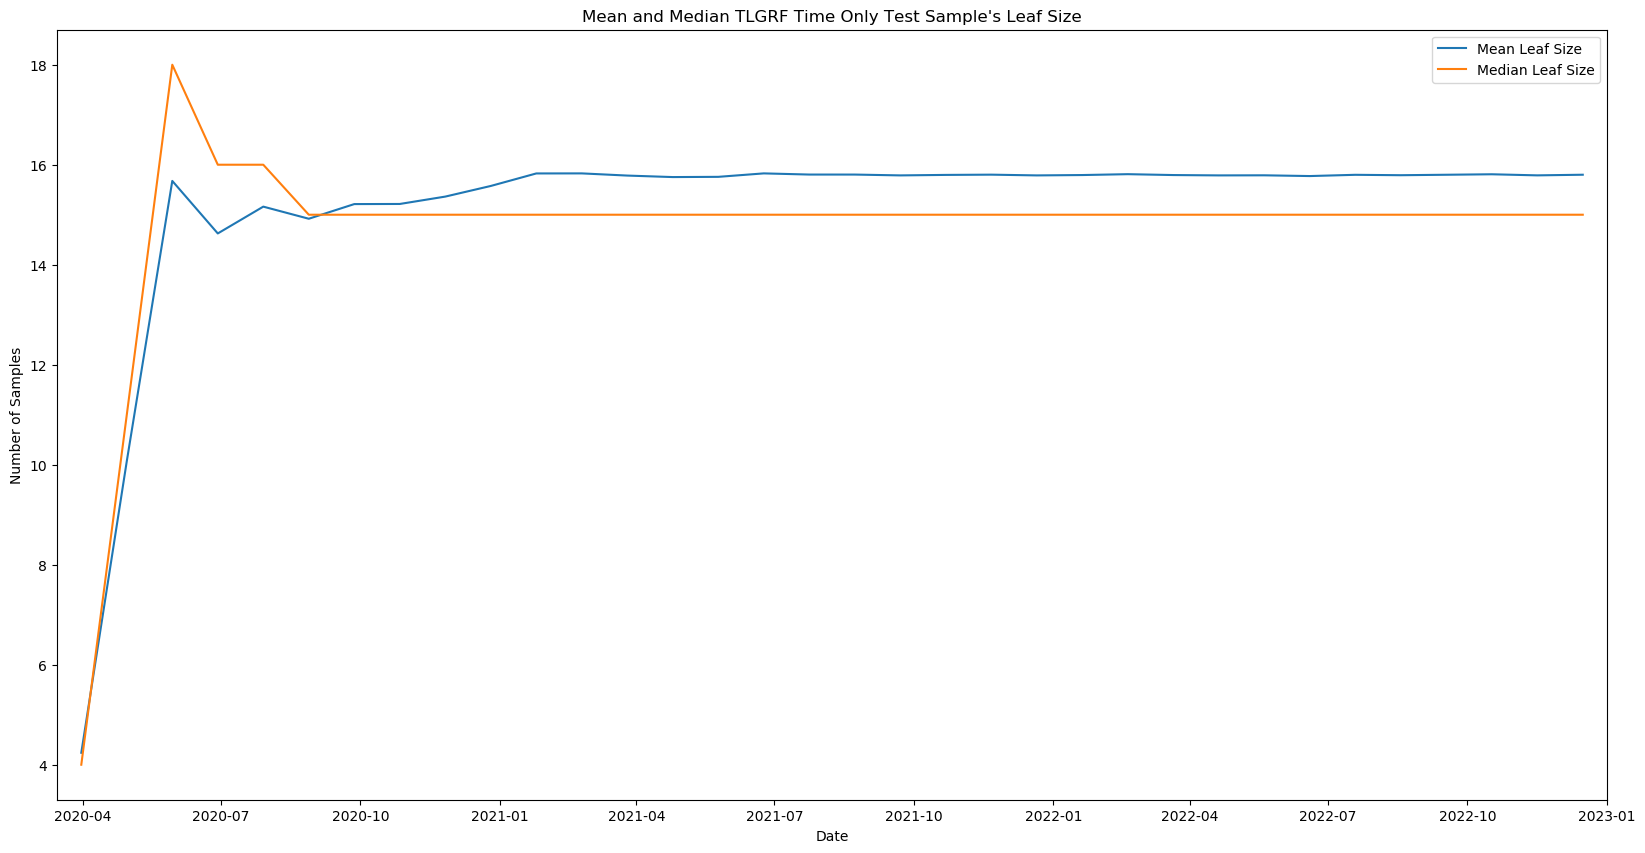

In [7]:
plt.figure(figsize=(20,10))
plt.plot(mean_leaf_size_by_cutoff, label="Mean Leaf Size")
plt.plot(median_leaf_size_by_cutoff, label="Median Leaf Size")

#plt.plot(mean_sample_size_by_cutoff, label="Mean Training Sample Size")
#plt.plot(median_sample_size_by_cutoff, label="Median Training Sample Size")

plt.xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))

plt.xlabel("Date")
plt.ylabel("Number of Samples")
plt.title("Mean and Median TLGRF Time Only Test Sample's Leaf Size")
plt.legend()

plt.show()

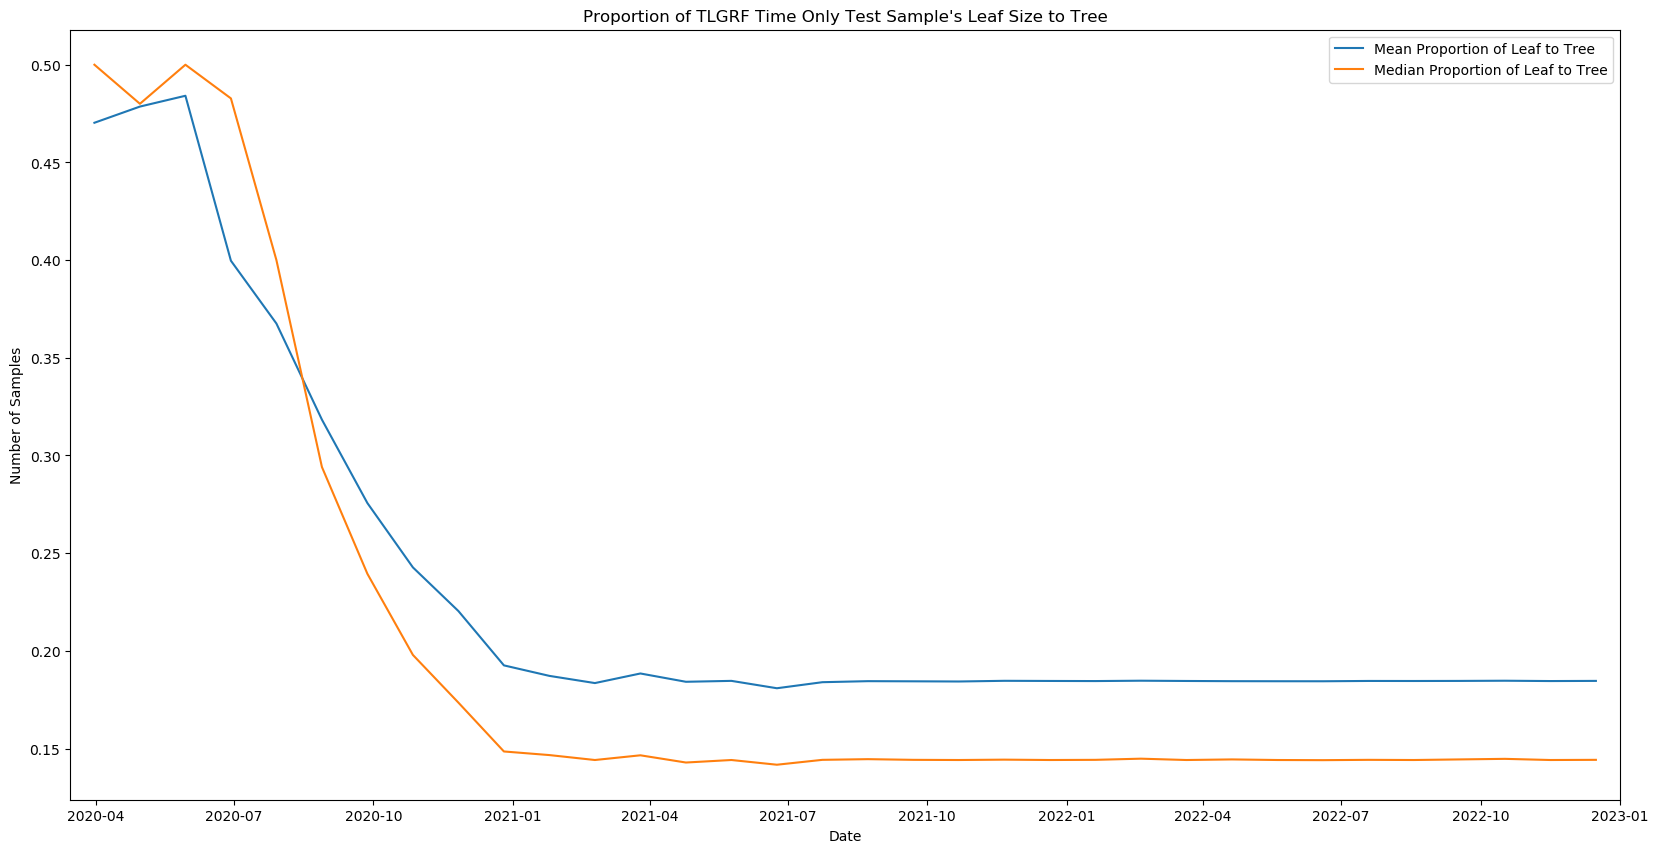

In [8]:
plt.figure(figsize=(20,10))
plt.plot(mean_ratio_by_cutoff, label="Mean Proportion of Leaf to Tree")
plt.plot(median_ratio_by_cutoff, label="Median Proportion of Leaf to Tree")

plt.xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))

plt.xlabel("Date")
plt.ylabel("Number of Samples")
plt.title("Proportion of TLGRF Time Only Test Sample's Leaf Size to Tree")
plt.legend()
plt.show()

In [9]:
TLGRF_Time_Only_leaf_and_tree_size_by_date = pd.DataFrame()
TLGRF_Time_Only_leaf_and_tree_size_by_date["Mean Leaf Size"] = mean_leaf_size_by_cutoff
TLGRF_Time_Only_leaf_and_tree_size_by_date["Median Leaf Size"] = median_leaf_size_by_cutoff

TLGRF_Time_Only_leaf_and_tree_size_by_date["Mean Tree Size"] = mean_sample_size_by_cutoff
TLGRF_Time_Only_leaf_and_tree_size_by_date["Median Tree Size"] = median_sample_size_by_cutoff

TLGRF_Time_Only_leaf_and_tree_size_by_date["Mean Ratio"] = mean_ratio_by_cutoff
TLGRF_Time_Only_leaf_and_tree_size_by_date["Median Ratio"] = median_ratio_by_cutoff

TLGRF_Time_Only_leaf_and_tree_size_by_date.to_csv("TLGRF_Time_Only_leaf_and_tree_size_by_date.csv", index=True)

TLGRF_Time_Only_leaf_and_tree_size_by_date

,Mean Leaf Size,Median Leaf Size,Mean Tree Size,Median Tree Size,Mean Ratio,Median Ratio
date,,,,,,
2020-03-31,4.239201,4.0,8.960880,9.0,0.470295,0.500000
2020-04-30,10.071321,11.0,20.985283,23.0,0.478578,0.480000
2020-05-30,15.675958,18.0,32.272889,36.0,0.484111,0.500000
2020-06-29,14.625454,16.0,39.424869,38.0,0.399681,0.482759
2020-07-29,15.161832,16.0,46.684817,46.0,0.367537,0.400000
2020-08-28,14.919532,15.0,55.934337,56.0,0.318354,0.294118
2020-09-27,15.212743,15.0,67.601730,71.0,0.275636,0.239437
2020-10-27,15.215086,15.0,78.943990,85.0,0.242722,0.197917
2020-11-26,15.362644,15.0,89.695940,97.0,0.220377,0.173512
